# XGBoost

#### Imports

In [15]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.xgb_experiment import XGBExperiment
from src.utils import evaluate_model, save_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Experimento 1: Conjunto com todas as Features

In [16]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### XGboost - Default

In [17]:
import xgboost as xgb

xgboost_exp1 = xgb.XGBClassifier(n_estimators=100, random_state=14)
xgboost_exp1.fit(X_train_exp1, y_train_exp1)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


=== Métricas xgb_def_exp1  ===
    Acurácia: 0.7838
    Precisão: 0.7538
    Recall:   0.7461
    F1-Score: 0.7496
    MCC:      0.4999
    AUC:      0.8459


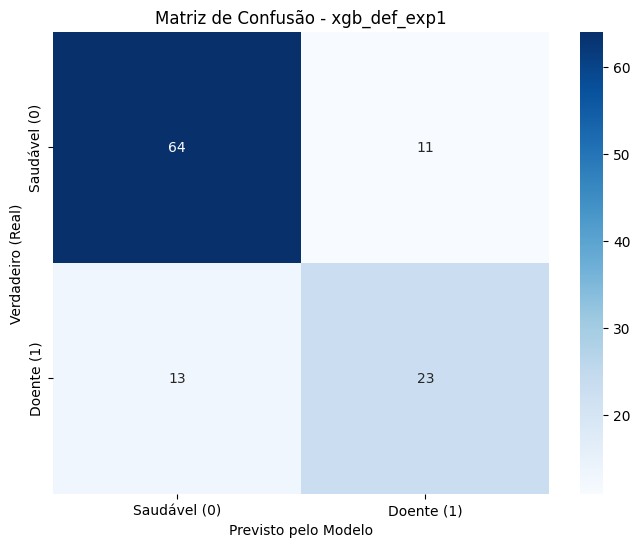

In [18]:
# Avaliar modelo
y_pred_def_exp1 = xgboost_exp1.predict(X_test_exp1)
y_prob_def_exp1 = xgboost_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'xgb_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'xgb_def_exp1', caminho)

### XGBoost - Melhorado

In [19]:
# Criar o experimento
experimento_1 = XGBExperiment(X_train_exp1, y_train_exp1, 'xgb_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_xgb = experimento_1.best_model

[I 2026-08-18 19:08:00,254] A new study created in memory with name: no-name-f0b14a0d-311d-45ee-8e26-fc1b5cfe3bb8


Iniciando otimização do cenário xgb_otz_exp1.


Best trial: 0. Best value: 0.813953:   2%|▏         | 1/50 [00:00<00:10,  4.54it/s]

[I 2026-08-18 19:08:00,474] Trial 0 finished with value: 0.813953488372093 and parameters: {'n_estimators': 236, 'max_depth': 6, 'learning_rate': 0.04305119411831094, 'subsample': 0.5939831959917987, 'colsample_bytree': 0.5488216599239887, 'gamma': 3.114770371898598}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:   4%|▍         | 2/50 [00:00<00:09,  4.90it/s]

[I 2026-08-18 19:08:00,665] Trial 1 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 260, 'max_depth': 9, 'learning_rate': 0.20095123079075605, 'subsample': 0.6793601603491131, 'colsample_bytree': 0.9449480913334145, 'gamma': 2.798601998724774}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:   8%|▊         | 4/50 [00:00<00:09,  5.02it/s]

[I 2026-08-18 19:08:00,900] Trial 2 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 276, 'max_depth': 5, 'learning_rate': 0.15921307819241706, 'subsample': 0.7260655083229743, 'colsample_bytree': 0.8157357469063933, 'gamma': 4.469646453852764}. Best is trial 0 with value: 0.813953488372093.
[I 2026-08-18 19:08:01,070] Trial 3 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 205, 'max_depth': 8, 'learning_rate': 0.26976016415261417, 'subsample': 0.7352273157035639, 'colsample_bytree': 0.6387567683912854, 'gamma': 2.31769733888671}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  10%|█         | 5/50 [00:00<00:08,  5.52it/s]

[I 2026-08-18 19:08:01,217] Trial 4 finished with value: 0.810077519379845 and parameters: {'n_estimators': 81, 'max_depth': 4, 'learning_rate': 0.03667113286559864, 'subsample': 0.5137779886540381, 'colsample_bytree': 0.995458230936923, 'gamma': 1.7028857297624111}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  14%|█▍        | 7/50 [00:01<00:07,  5.71it/s]

[I 2026-08-18 19:08:01,420] Trial 5 finished with value: 0.810077519379845 and parameters: {'n_estimators': 154, 'max_depth': 4, 'learning_rate': 0.037830567485864296, 'subsample': 0.6168449393849287, 'colsample_bytree': 0.5764944113610455, 'gamma': 1.3862495045439926}. Best is trial 0 with value: 0.813953488372093.
[I 2026-08-18 19:08:01,567] Trial 6 finished with value: 0.813953488372093 and parameters: {'n_estimators': 127, 'max_depth': 5, 'learning_rate': 0.04599148945367183, 'subsample': 0.5862876115115397, 'colsample_bytree': 0.8391578117048006, 'gamma': 4.8889534287852605}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  16%|█▌        | 8/50 [00:01<00:08,  4.86it/s]

[I 2026-08-18 19:08:01,839] Trial 7 finished with value: 0.810077519379845 and parameters: {'n_estimators': 286, 'max_depth': 5, 'learning_rate': 0.021079175509438983, 'subsample': 0.8785844328890127, 'colsample_bytree': 0.5201866858007944, 'gamma': 3.356040454277485}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  18%|█▊        | 9/50 [00:02<00:11,  3.50it/s]

[I 2026-08-18 19:08:02,284] Trial 8 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 264, 'max_depth': 6, 'learning_rate': 0.05021236056500769, 'subsample': 0.5731098121118654, 'colsample_bytree': 0.9169564343773554, 'gamma': 4.613692387850569}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  20%|██        | 10/50 [00:02<00:15,  2.61it/s]

[I 2026-08-18 19:08:02,895] Trial 9 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 156, 'max_depth': 10, 'learning_rate': 0.015278320477029572, 'subsample': 0.5169588375515219, 'colsample_bytree': 0.7643329494720195, 'gamma': 0.5611184350921655}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  22%|██▏       | 11/50 [00:02<00:14,  2.71it/s]

[I 2026-08-18 19:08:03,241] Trial 10 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 214, 'max_depth': 7, 'learning_rate': 0.08685700497838555, 'subsample': 0.9959240271455031, 'colsample_bytree': 0.6701403499984872, 'gamma': 3.296809468674}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  24%|██▍       | 12/50 [00:03<00:12,  3.12it/s]

[I 2026-08-18 19:08:03,449] Trial 11 finished with value: 0.813953488372093 and parameters: {'n_estimators': 95, 'max_depth': 3, 'learning_rate': 0.08705460956406597, 'subsample': 0.6366512562087977, 'colsample_bytree': 0.8483305739383024, 'gamma': 3.8923602484701547}. Best is trial 0 with value: 0.813953488372093.


Best trial: 0. Best value: 0.813953:  26%|██▌       | 13/50 [00:03<00:11,  3.24it/s]

[I 2026-08-18 19:08:03,723] Trial 12 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 131, 'max_depth': 7, 'learning_rate': 0.02699168364989859, 'subsample': 0.8115709413330394, 'colsample_bytree': 0.730309016477967, 'gamma': 4.963320471579102}. Best is trial 0 with value: 0.813953488372093.


Best trial: 13. Best value: 0.821705:  28%|██▊       | 14/50 [00:03<00:11,  3.24it/s]

[I 2026-08-18 19:08:04,042] Trial 13 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 192, 'max_depth': 6, 'learning_rate': 0.07560875523243732, 'subsample': 0.5828728182078582, 'colsample_bytree': 0.8463309730535687, 'gamma': 3.9766785203539534}. Best is trial 13 with value: 0.8217054263565892.


Best trial: 13. Best value: 0.821705:  30%|███       | 15/50 [00:04<00:12,  2.89it/s]

[I 2026-08-18 19:08:04,465] Trial 14 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 213, 'max_depth': 6, 'learning_rate': 0.08702455004521349, 'subsample': 0.6682677915063766, 'colsample_bytree': 0.506088461587591, 'gamma': 3.8355599017828563}. Best is trial 13 with value: 0.8217054263565892.


Best trial: 13. Best value: 0.821705:  32%|███▏      | 16/50 [00:06<00:32,  1.04it/s]

[I 2026-08-18 19:08:06,839] Trial 15 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 241, 'max_depth': 8, 'learning_rate': 0.010522498877321302, 'subsample': 0.812525330314412, 'colsample_bytree': 0.6899914249604748, 'gamma': 2.5938580598584697}. Best is trial 13 with value: 0.8217054263565892.


Best trial: 13. Best value: 0.821705:  34%|███▍      | 17/50 [00:10<00:57,  1.75s/it]

[I 2026-08-18 19:08:10,443] Trial 16 finished with value: 0.7984496124031008 and parameters: {'n_estimators': 189, 'max_depth': 8, 'learning_rate': 0.010929854966003148, 'subsample': 0.8549255050673434, 'colsample_bytree': 0.7172576679452984, 'gamma': 2.2902149503430755}. Best is trial 13 with value: 0.8217054263565892.


Best trial: 13. Best value: 0.821705:  36%|███▌      | 18/50 [00:11<00:48,  1.52s/it]

[I 2026-08-18 19:08:11,420] Trial 17 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 238, 'max_depth': 8, 'learning_rate': 0.12432907224600896, 'subsample': 0.799269048507154, 'colsample_bytree': 0.6332270812936602, 'gamma': 0.21586996331065667}. Best is trial 13 with value: 0.8217054263565892.


Best trial: 13. Best value: 0.821705:  38%|███▊      | 19/50 [00:11<00:36,  1.18s/it]

[I 2026-08-18 19:08:11,811] Trial 18 finished with value: 0.7364341085271318 and parameters: {'n_estimators': 56, 'max_depth': 9, 'learning_rate': 0.010507381452591244, 'subsample': 0.9425809110834448, 'colsample_bytree': 0.7779256195826656, 'gamma': 4.024720645327528}. Best is trial 13 with value: 0.8217054263565892.


Best trial: 19. Best value: 0.825581:  40%|████      | 20/50 [00:12<00:30,  1.03s/it]

[I 2026-08-18 19:08:12,497] Trial 19 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 173, 'max_depth': 10, 'learning_rate': 0.06320983850030118, 'subsample': 0.7843091802961553, 'colsample_bytree': 0.9019729494346076, 'gamma': 1.513623382269118}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  42%|████▏     | 21/50 [00:12<00:26,  1.08it/s]

[I 2026-08-18 19:08:13,164] Trial 20 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 174, 'max_depth': 10, 'learning_rate': 0.06150121906381329, 'subsample': 0.7006481716751655, 'colsample_bytree': 0.8791119603636729, 'gamma': 1.6125149007973576}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  44%|████▍     | 22/50 [00:13<00:24,  1.14it/s]

[I 2026-08-18 19:08:13,930] Trial 21 finished with value: 0.8255813953488372 and parameters: {'n_estimators': 237, 'max_depth': 9, 'learning_rate': 0.0768647244383858, 'subsample': 0.7896469763269365, 'colsample_bytree': 0.9042683802746248, 'gamma': 1.1916067322829416}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  46%|████▌     | 23/50 [00:14<00:22,  1.19it/s]

[I 2026-08-18 19:08:14,679] Trial 22 finished with value: 0.813953488372093 and parameters: {'n_estimators': 175, 'max_depth': 9, 'learning_rate': 0.06553087649533626, 'subsample': 0.7739620172154306, 'colsample_bytree': 0.9066291597657457, 'gamma': 0.8795254042431984}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  48%|████▊     | 24/50 [00:15<00:20,  1.29it/s]

[I 2026-08-18 19:08:15,321] Trial 23 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 190, 'max_depth': 10, 'learning_rate': 0.11012877089400872, 'subsample': 0.8732272349031988, 'colsample_bytree': 0.9542699405783877, 'gamma': 1.0811020489283654}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  50%|█████     | 25/50 [00:15<00:17,  1.39it/s]

[I 2026-08-18 19:08:15,903] Trial 24 finished with value: 0.810077519379845 and parameters: {'n_estimators': 153, 'max_depth': 9, 'learning_rate': 0.06887793246572188, 'subsample': 0.7650034152486691, 'colsample_bytree': 0.8173783479179472, 'gamma': 1.9803957381452393}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  52%|█████▏    | 26/50 [00:16<00:17,  1.40it/s]

[I 2026-08-18 19:08:16,601] Trial 25 finished with value: 0.7868217054263567 and parameters: {'n_estimators': 228, 'max_depth': 7, 'learning_rate': 0.1397400452888536, 'subsample': 0.8455360559106893, 'colsample_bytree': 0.8831109608515557, 'gamma': 1.061646180652008}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  54%|█████▍    | 27/50 [00:17<00:20,  1.14it/s]

[I 2026-08-18 19:08:17,863] Trial 26 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 131, 'max_depth': 10, 'learning_rate': 0.030486749640118504, 'subsample': 0.9168399169408421, 'colsample_bytree': 0.999312321864443, 'gamma': 0.06520751415515424}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  56%|█████▌    | 28/50 [00:18<00:17,  1.23it/s]

[I 2026-08-18 19:08:18,522] Trial 27 finished with value: 0.810077519379845 and parameters: {'n_estimators': 195, 'max_depth': 9, 'learning_rate': 0.09888905457632288, 'subsample': 0.7127299764922684, 'colsample_bytree': 0.7929726160439209, 'gamma': 2.0618743034814297}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  58%|█████▊    | 29/50 [00:18<00:16,  1.31it/s]

[I 2026-08-18 19:08:19,180] Trial 28 finished with value: 0.810077519379845 and parameters: {'n_estimators': 175, 'max_depth': 10, 'learning_rate': 0.1755467198949165, 'subsample': 0.7634038684371575, 'colsample_bytree': 0.8662628139872506, 'gamma': 0.48815594781085614}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  60%|██████    | 30/50 [00:19<00:15,  1.28it/s]

[I 2026-08-18 19:08:19,997] Trial 29 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 227, 'max_depth': 6, 'learning_rate': 0.07231291014469142, 'subsample': 0.6501850644624508, 'colsample_bytree': 0.946147293099807, 'gamma': 1.3704402500110042}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 19. Best value: 0.825581:  62%|██████▏   | 31/50 [00:20<00:16,  1.12it/s]

[I 2026-08-18 19:08:21,144] Trial 30 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 252, 'max_depth': 7, 'learning_rate': 0.05160175668377948, 'subsample': 0.5367081398421873, 'colsample_bytree': 0.9099415880944431, 'gamma': 0.7768246165027375}. Best is trial 19 with value: 0.8255813953488372.


Best trial: 31. Best value: 0.829457:  64%|██████▍   | 32/50 [00:21<00:14,  1.27it/s]

[I 2026-08-18 19:08:21,696] Trial 31 finished with value: 0.8294573643410853 and parameters: {'n_estimators': 185, 'max_depth': 10, 'learning_rate': 0.11032976402760579, 'subsample': 0.8917080128191283, 'colsample_bytree': 0.9573554022879894, 'gamma': 1.2664263338851662}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  66%|██████▌   | 33/50 [00:21<00:12,  1.42it/s]

[I 2026-08-18 19:08:22,211] Trial 32 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 202, 'max_depth': 10, 'learning_rate': 0.1306919403515095, 'subsample': 0.9103971855447843, 'colsample_bytree': 0.969938325757448, 'gamma': 2.963073128485104}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  68%|██████▊   | 34/50 [00:22<00:09,  1.61it/s]

[I 2026-08-18 19:08:22,634] Trial 33 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 158, 'max_depth': 9, 'learning_rate': 0.2254135227335791, 'subsample': 0.786608880081997, 'colsample_bytree': 0.9204739668824462, 'gamma': 1.3992969750358328}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  70%|███████   | 35/50 [00:23<00:09,  1.54it/s]

[I 2026-08-18 19:08:23,340] Trial 34 finished with value: 0.813953488372093 and parameters: {'n_estimators': 298, 'max_depth': 10, 'learning_rate': 0.07906799134901317, 'subsample': 0.9576551339800233, 'colsample_bytree': 0.9733471640837464, 'gamma': 1.7573470414006633}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  72%|███████▏  | 36/50 [00:23<00:09,  1.47it/s]

[I 2026-08-18 19:08:24,094] Trial 35 finished with value: 0.8217054263565892 and parameters: {'n_estimators': 221, 'max_depth': 8, 'learning_rate': 0.11437477939227603, 'subsample': 0.8354706037359341, 'colsample_bytree': 0.825346708482225, 'gamma': 2.665713949598601}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  74%|███████▍  | 37/50 [00:24<00:09,  1.35it/s]

[I 2026-08-18 19:08:24,980] Trial 36 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 249, 'max_depth': 9, 'learning_rate': 0.05589301784257887, 'subsample': 0.7517787398034476, 'colsample_bytree': 0.8824186565556049, 'gamma': 2.0505549976688497}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  76%|███████▌  | 38/50 [00:25<00:09,  1.33it/s]

[I 2026-08-18 19:08:25,757] Trial 37 finished with value: 0.810077519379845 and parameters: {'n_estimators': 107, 'max_depth': 4, 'learning_rate': 0.036413460639413066, 'subsample': 0.6887771929161032, 'colsample_bytree': 0.931419262215691, 'gamma': 1.2334275204267866}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  78%|███████▊  | 39/50 [00:25<00:07,  1.55it/s]

[I 2026-08-18 19:08:26,150] Trial 38 finished with value: 0.813953488372093 and parameters: {'n_estimators': 144, 'max_depth': 5, 'learning_rate': 0.15761768665835527, 'subsample': 0.7369625177654255, 'colsample_bytree': 0.9693032347423756, 'gamma': 1.6488534503944092}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  80%|████████  | 40/50 [00:26<00:06,  1.52it/s]

[I 2026-08-18 19:08:26,836] Trial 39 finished with value: 0.813953488372093 and parameters: {'n_estimators': 269, 'max_depth': 9, 'learning_rate': 0.0407147237183078, 'subsample': 0.907967915794931, 'colsample_bytree': 0.8504711652149037, 'gamma': 0.6871623631827487}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  82%|████████▏ | 41/50 [00:26<00:05,  1.78it/s]

[I 2026-08-18 19:08:27,177] Trial 40 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 175, 'max_depth': 8, 'learning_rate': 0.28929236350106685, 'subsample': 0.5609276651423457, 'colsample_bytree': 0.8029967577152031, 'gamma': 4.254813914311413}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  84%|████████▍ | 42/50 [00:27<00:04,  1.78it/s]

[I 2026-08-18 19:08:27,734] Trial 41 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 195, 'max_depth': 10, 'learning_rate': 0.10970158296813382, 'subsample': 0.8955106112803526, 'colsample_bytree': 0.9481805519696593, 'gamma': 1.087387714327015}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  86%|████████▌ | 43/50 [00:28<00:05,  1.37it/s]

[I 2026-08-18 19:08:28,857] Trial 42 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 190, 'max_depth': 10, 'learning_rate': 0.10697613127497602, 'subsample': 0.8600395134354436, 'colsample_bytree': 0.8982537274211719, 'gamma': 0.3504113625466424}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  88%|████████▊ | 44/50 [00:30<00:06,  1.07s/it]

[I 2026-08-18 19:08:30,702] Trial 43 finished with value: 0.813953488372093 and parameters: {'n_estimators': 163, 'max_depth': 10, 'learning_rate': 0.09460690097837217, 'subsample': 0.826314214143624, 'colsample_bytree': 0.9475362055844176, 'gamma': 0.9670526782686002}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  90%|█████████ | 45/50 [00:31<00:05,  1.03s/it]

[I 2026-08-18 19:08:31,673] Trial 44 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 187, 'max_depth': 10, 'learning_rate': 0.20260804882118874, 'subsample': 0.8834367020441701, 'colsample_bytree': 0.8602353938281201, 'gamma': 3.5283086665868253}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  92%|█████████▏| 46/50 [00:32<00:03,  1.04it/s]

[I 2026-08-18 19:08:32,476] Trial 45 finished with value: 0.810077519379845 and parameters: {'n_estimators': 207, 'max_depth': 6, 'learning_rate': 0.058171524532303794, 'subsample': 0.9445667418653828, 'colsample_bytree': 0.9855567115464646, 'gamma': 2.341036113048432}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  94%|█████████▍| 47/50 [00:33<00:02,  1.06it/s]

[I 2026-08-18 19:08:33,367] Trial 46 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 215, 'max_depth': 9, 'learning_rate': 0.04583120042812834, 'subsample': 0.8721355397640366, 'colsample_bytree': 0.9430422900395665, 'gamma': 1.410742836372503}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  96%|█████████▌| 48/50 [00:33<00:01,  1.19it/s]

[I 2026-08-18 19:08:33,974] Trial 47 finished with value: 0.813953488372093 and parameters: {'n_estimators': 141, 'max_depth': 10, 'learning_rate': 0.08133841811245822, 'subsample': 0.6156585095333562, 'colsample_bytree': 0.8972519737749312, 'gamma': 1.797467893585762}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457:  98%|█████████▊| 49/50 [00:34<00:00,  1.29it/s]

[I 2026-08-18 19:08:34,588] Trial 48 finished with value: 0.810077519379845 and parameters: {'n_estimators': 111, 'max_depth': 9, 'learning_rate': 0.07386314462484155, 'subsample': 0.7172218248188733, 'colsample_bytree': 0.9234449514378484, 'gamma': 1.1836911030648176}. Best is trial 31 with value: 0.8294573643410853.


Best trial: 31. Best value: 0.829457: 100%|██████████| 50/50 [00:34<00:00,  1.43it/s]


[I 2026-08-18 19:08:35,213] Trial 49 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 167, 'max_depth': 6, 'learning_rate': 0.14689677224410286, 'subsample': 0.9728065312219767, 'colsample_bytree': 0.8336745695373361, 'gamma': 4.695885142110134}. Best is trial 31 with value: 0.8294573643410853.
Melhor pontuação (CV): 0.8295
Melhores parâmetros:
{'n_estimators': 185, 'max_depth': 10, 'learning_rate': 0.11032976402760579, 'subsample': 0.8917080128191283, 'colsample_bytree': 0.9573554022879894, 'gamma': 1.2664263338851662}


In [20]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===
      feature  importance
  eosinophils      0.1471
  lymphocytes      0.0872
    platelets      0.0824
 neutrophilsP      0.0651
  hematocritP      0.0510
   basophilsP      0.0481
   leukocytes      0.0427
 lymphocytesP      0.0420
          mpv      0.0408
redbloodcells      0.0406
         rdwP      0.0391
    monocytes      0.0388
   monocytesP      0.0382
         mchc      0.0382
          mch      0.0379
   hemoglobin      0.0344
 eosinophilsP      0.0341
    basophils      0.0339
          mcv      0.0301
  neutrophils      0.0285


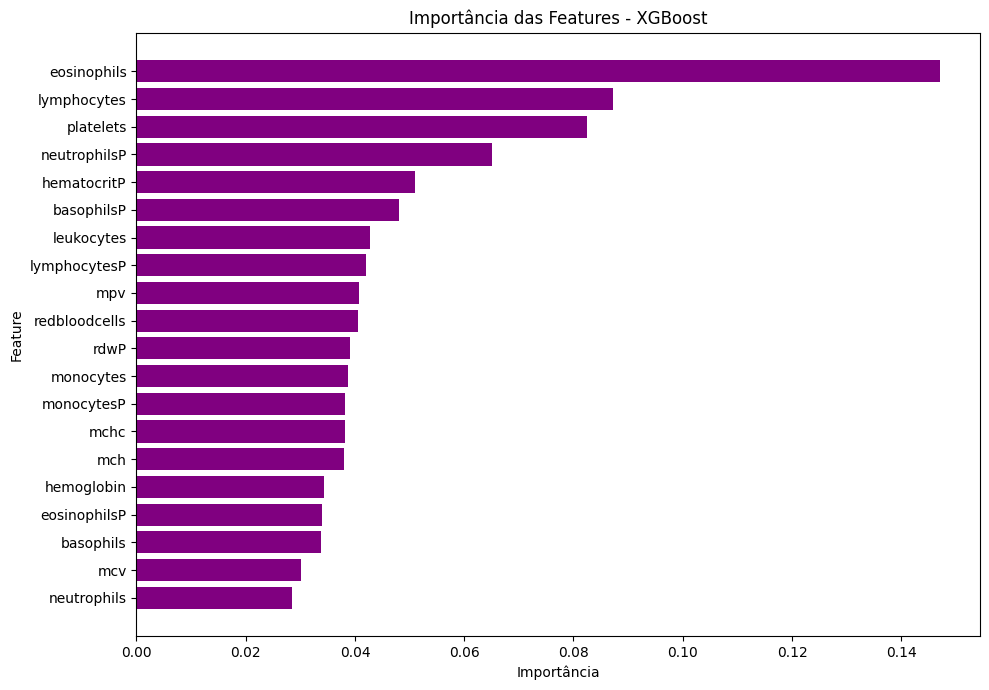

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do XGBoost
feature_importance = pd.DataFrame({
    'feature': X_train_exp1.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='purple')
plt.title('Importância das Features - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Métricas xgb_otz_exp1  ===
    Acurácia: 0.7838
    Precisão: 0.7533
    Recall:   0.7533
    F1-Score: 0.7533
    MCC:      0.5067
    AUC:      0.8419


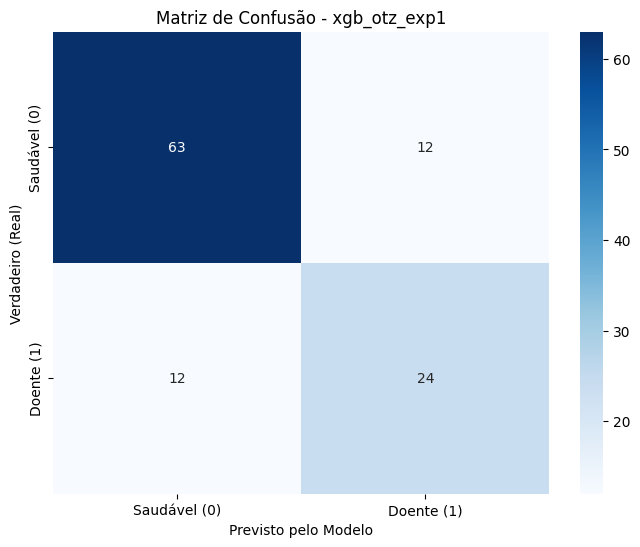

In [22]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'xgb_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'xgb_otz_exp1', caminho)

## Experimento 2: Conjunto com PCA

In [23]:
X_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_test_pca.csv')
X_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_train_pca.csv')
y_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### XGBoost - Default

In [24]:
import xgboost as xgb

xgboost_exp2 = xgb.XGBClassifier(n_estimators=100, random_state=14)
xgboost_exp2.fit(X_train_exp2, y_train_exp2)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


=== Métricas xgb_def_exp2  ===
    Acurácia: 0.7477
    Precisão: 0.7112
    Recall:   0.6978
    F1-Score: 0.7032
    MCC:      0.4088
    AUC:      0.8278


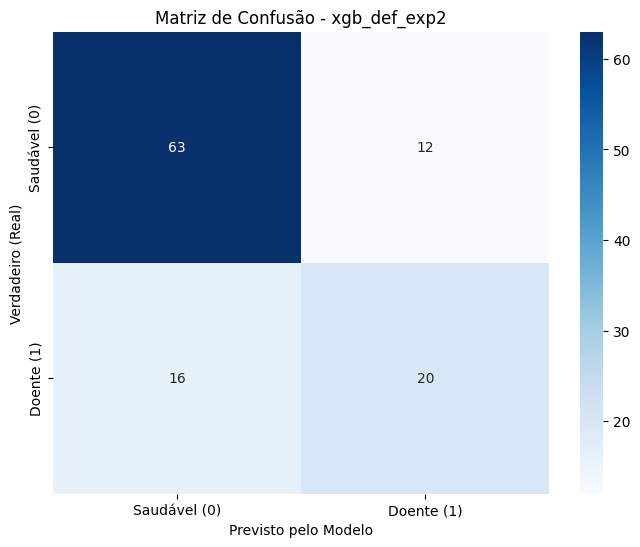

In [25]:
# Avaliar modelo
y_pred_def_exp2 = xgboost_exp2.predict(X_test_exp2)
y_prob_def_exp2 = xgboost_exp2.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_def_exp2, y_prob_def_exp2, 'xgb_def_exp2')
save_results(y_pred_def_exp2, y_prob_def_exp2, 'xgb_def_exp2', caminho)

### XGBoost - Melhorado

In [26]:
# Criar o experimento
experimento_2 = XGBExperiment(X_train_exp2, y_train_exp2, 'xgb_otz_exp2', caminho)
experimento_2.tune_and_fit(n_trials=50)

[I 2026-08-18 19:08:42,230] A new study created in memory with name: no-name-79e948e2-c180-4780-8306-707ec6e94aac


Iniciando otimização do cenário xgb_otz_exp2.


Best trial: 0. Best value: 0.771318:   2%|▏         | 1/50 [00:01<00:49,  1.02s/it]

[I 2026-08-18 19:08:43,250] Trial 0 finished with value: 0.7713178294573644 and parameters: {'n_estimators': 147, 'max_depth': 4, 'learning_rate': 0.020876338152080478, 'subsample': 0.9792513866942545, 'colsample_bytree': 0.7203839525872657, 'gamma': 1.6082394455343085}. Best is trial 0 with value: 0.7713178294573644.


Best trial: 1. Best value: 0.790698:   4%|▍         | 2/50 [00:01<00:33,  1.42it/s]

[I 2026-08-18 19:08:43,734] Trial 1 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 52, 'max_depth': 8, 'learning_rate': 0.18526103783403358, 'subsample': 0.7428763134428495, 'colsample_bytree': 0.6038626840617755, 'gamma': 0.007997655055178021}. Best is trial 1 with value: 0.7906976744186047.


Best trial: 1. Best value: 0.790698:   6%|▌         | 3/50 [00:02<00:38,  1.21it/s]

[I 2026-08-18 19:08:44,716] Trial 2 finished with value: 0.7868217054263567 and parameters: {'n_estimators': 168, 'max_depth': 7, 'learning_rate': 0.01400568314439669, 'subsample': 0.6774522996870165, 'colsample_bytree': 0.7335213531534464, 'gamma': 1.1454878280516267}. Best is trial 1 with value: 0.7906976744186047.


Best trial: 1. Best value: 0.790698:   8%|▊         | 4/50 [00:02<00:32,  1.43it/s]

[I 2026-08-18 19:08:45,219] Trial 3 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 177, 'max_depth': 10, 'learning_rate': 0.16402609870963336, 'subsample': 0.9144966203514497, 'colsample_bytree': 0.7913656399102635, 'gamma': 2.1934142272601695}. Best is trial 1 with value: 0.7906976744186047.


Best trial: 1. Best value: 0.790698:  10%|█         | 5/50 [00:03<00:35,  1.25it/s]

[I 2026-08-18 19:08:46,190] Trial 4 finished with value: 0.7790697674418605 and parameters: {'n_estimators': 292, 'max_depth': 5, 'learning_rate': 0.04175070467737577, 'subsample': 0.9223836251981143, 'colsample_bytree': 0.9293204043419524, 'gamma': 1.0177156302404544}. Best is trial 1 with value: 0.7906976744186047.


Best trial: 5. Best value: 0.806202:  12%|█▏        | 6/50 [00:04<00:34,  1.29it/s]

[I 2026-08-18 19:08:46,909] Trial 5 finished with value: 0.806201550387597 and parameters: {'n_estimators': 218, 'max_depth': 3, 'learning_rate': 0.039774700192789794, 'subsample': 0.577028850098346, 'colsample_bytree': 0.5578809195025982, 'gamma': 1.8677318666019587}. Best is trial 5 with value: 0.806201550387597.


Best trial: 5. Best value: 0.806202:  14%|█▍        | 7/50 [00:05<00:28,  1.49it/s]

[I 2026-08-18 19:08:47,380] Trial 6 finished with value: 0.7751937984496124 and parameters: {'n_estimators': 156, 'max_depth': 6, 'learning_rate': 0.15166914940273027, 'subsample': 0.7771326269757122, 'colsample_bytree': 0.8539337770781819, 'gamma': 1.6996436305366154}. Best is trial 5 with value: 0.806201550387597.


Best trial: 5. Best value: 0.806202:  16%|█▌        | 8/50 [00:05<00:27,  1.52it/s]

[I 2026-08-18 19:08:48,003] Trial 7 finished with value: 0.806201550387597 and parameters: {'n_estimators': 186, 'max_depth': 8, 'learning_rate': 0.030004648253300393, 'subsample': 0.529124148611934, 'colsample_bytree': 0.8855612631030444, 'gamma': 3.453109955499051}. Best is trial 5 with value: 0.806201550387597.


Best trial: 5. Best value: 0.806202:  18%|█▊        | 9/50 [00:06<00:21,  1.89it/s]

[I 2026-08-18 19:08:48,251] Trial 8 finished with value: 0.7751937984496124 and parameters: {'n_estimators': 62, 'max_depth': 8, 'learning_rate': 0.27674359846846686, 'subsample': 0.9642088852564628, 'colsample_bytree': 0.9445570709353137, 'gamma': 1.2775834300277178}. Best is trial 5 with value: 0.806201550387597.


Best trial: 5. Best value: 0.806202:  20%|██        | 10/50 [00:06<00:19,  2.01it/s]

[I 2026-08-18 19:08:48,683] Trial 9 finished with value: 0.7713178294573644 and parameters: {'n_estimators': 51, 'max_depth': 4, 'learning_rate': 0.12208457692721002, 'subsample': 0.5343312043172571, 'colsample_bytree': 0.7341881376870745, 'gamma': 0.016931672393724617}. Best is trial 5 with value: 0.806201550387597.


Best trial: 5. Best value: 0.806202:  22%|██▏       | 11/50 [00:07<00:22,  1.75it/s]

[I 2026-08-18 19:08:49,422] Trial 10 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 259, 'max_depth': 3, 'learning_rate': 0.07272178085206235, 'subsample': 0.631312263487016, 'colsample_bytree': 0.5014131684009575, 'gamma': 4.086919809030967}. Best is trial 5 with value: 0.806201550387597.


Best trial: 11. Best value: 0.817829:  24%|██▍       | 12/50 [00:08<00:25,  1.52it/s]

[I 2026-08-18 19:08:50,274] Trial 11 finished with value: 0.8178294573643411 and parameters: {'n_estimators': 224, 'max_depth': 10, 'learning_rate': 0.034772591572933095, 'subsample': 0.5117388910718842, 'colsample_bytree': 0.6072443508029716, 'gamma': 3.544731868516364}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  26%|██▌       | 13/50 [00:08<00:24,  1.48it/s]

[I 2026-08-18 19:08:50,986] Trial 12 finished with value: 0.806201550387597 and parameters: {'n_estimators': 242, 'max_depth': 10, 'learning_rate': 0.07036999385259066, 'subsample': 0.5008271504720625, 'colsample_bytree': 0.5993516941665477, 'gamma': 3.202185630198734}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  28%|██▊       | 14/50 [00:09<00:22,  1.58it/s]

[I 2026-08-18 19:08:51,529] Trial 13 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 215, 'max_depth': 3, 'learning_rate': 0.04034109303842618, 'subsample': 0.6032258703169698, 'colsample_bytree': 0.5893250022973062, 'gamma': 4.794667113098219}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  30%|███       | 15/50 [00:10<00:31,  1.11it/s]

[I 2026-08-18 19:08:53,048] Trial 14 finished with value: 0.7868217054263567 and parameters: {'n_estimators': 120, 'max_depth': 9, 'learning_rate': 0.011871419658601527, 'subsample': 0.5887510952504812, 'colsample_bytree': 0.5028979902515245, 'gamma': 2.7952298135470444}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  32%|███▏      | 16/50 [00:11<00:30,  1.12it/s]

[I 2026-08-18 19:08:53,932] Trial 15 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 219, 'max_depth': 6, 'learning_rate': 0.02392529272389216, 'subsample': 0.7027846560480013, 'colsample_bytree': 0.6428284290696583, 'gamma': 3.9929472471650573}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  34%|███▍      | 17/50 [00:12<00:29,  1.11it/s]

[I 2026-08-18 19:08:54,834] Trial 16 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 287, 'max_depth': 5, 'learning_rate': 0.055877320767879754, 'subsample': 0.5532939069768068, 'colsample_bytree': 0.6745108733605822, 'gamma': 2.4387124249163534}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  36%|███▌      | 18/50 [00:13<00:25,  1.23it/s]

[I 2026-08-18 19:08:55,451] Trial 17 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 209, 'max_depth': 7, 'learning_rate': 0.09385354549709639, 'subsample': 0.8122956932564628, 'colsample_bytree': 0.5552805184649549, 'gamma': 4.754573959871257}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  38%|███▊      | 19/50 [00:13<00:24,  1.25it/s]

[I 2026-08-18 19:08:56,231] Trial 18 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 241, 'max_depth': 9, 'learning_rate': 0.036671964671607854, 'subsample': 0.6551346116228529, 'colsample_bytree': 0.6631551338632157, 'gamma': 3.6234033671113046}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  40%|████      | 20/50 [00:14<00:21,  1.38it/s]

[I 2026-08-18 19:08:56,766] Trial 19 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 114, 'max_depth': 5, 'learning_rate': 0.020140094319433637, 'subsample': 0.5849162006908222, 'colsample_bytree': 0.5486897159108558, 'gamma': 3.0360598442802638}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  42%|████▏     | 21/50 [00:15<00:21,  1.32it/s]

[I 2026-08-18 19:08:57,606] Trial 20 finished with value: 0.7751937984496124 and parameters: {'n_estimators': 265, 'max_depth': 4, 'learning_rate': 0.052882462180388515, 'subsample': 0.8206513627107, 'colsample_bytree': 0.9943999904151156, 'gamma': 2.1105225376702057}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  44%|████▍     | 22/50 [00:16<00:20,  1.35it/s]

[I 2026-08-18 19:08:58,301] Trial 21 finished with value: 0.810077519379845 and parameters: {'n_estimators': 190, 'max_depth': 9, 'learning_rate': 0.028901209265235168, 'subsample': 0.5040389950047752, 'colsample_bytree': 0.8193600003166537, 'gamma': 3.6459629455780265}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  46%|████▌     | 23/50 [00:16<00:19,  1.40it/s]

[I 2026-08-18 19:08:58,951] Trial 22 finished with value: 0.813953488372093 and parameters: {'n_estimators': 197, 'max_depth': 9, 'learning_rate': 0.028520804979707992, 'subsample': 0.5098842689406312, 'colsample_bytree': 0.8026028007890531, 'gamma': 4.159328163078375}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  48%|████▊     | 24/50 [00:17<00:17,  1.45it/s]

[I 2026-08-18 19:08:59,591] Trial 23 finished with value: 0.806201550387597 and parameters: {'n_estimators': 195, 'max_depth': 9, 'learning_rate': 0.02426495970803576, 'subsample': 0.5117317021976926, 'colsample_bytree': 0.7822589600729035, 'gamma': 4.2800613233175655}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  50%|█████     | 25/50 [00:18<00:17,  1.43it/s]

[I 2026-08-18 19:09:00,320] Trial 24 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 147, 'max_depth': 10, 'learning_rate': 0.015805019986908725, 'subsample': 0.5004119125085597, 'colsample_bytree': 0.7987138375545795, 'gamma': 3.7697502153769458}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  52%|█████▏    | 26/50 [00:18<00:16,  1.43it/s]

[I 2026-08-18 19:09:01,018] Trial 25 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 197, 'max_depth': 9, 'learning_rate': 0.030644509658732364, 'subsample': 0.5508053354296178, 'colsample_bytree': 0.8349499252410887, 'gamma': 4.470474666227011}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  54%|█████▍    | 27/50 [00:19<00:16,  1.37it/s]

[I 2026-08-18 19:09:01,821] Trial 26 finished with value: 0.7829457364341086 and parameters: {'n_estimators': 235, 'max_depth': 10, 'learning_rate': 0.010142695783961356, 'subsample': 0.620362114486948, 'colsample_bytree': 0.6958378601656735, 'gamma': 4.999249747546108}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  56%|█████▌    | 28/50 [00:20<00:14,  1.48it/s]

[I 2026-08-18 19:09:02,372] Trial 27 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 129, 'max_depth': 8, 'learning_rate': 0.03080142877134393, 'subsample': 0.5567177266432002, 'colsample_bytree': 0.8299545846548056, 'gamma': 2.8017826895704427}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  58%|█████▊    | 29/50 [00:21<00:15,  1.33it/s]

[I 2026-08-18 19:09:03,302] Trial 28 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 265, 'max_depth': 9, 'learning_rate': 0.015568906648471617, 'subsample': 0.710864883703352, 'colsample_bytree': 0.8823947791887068, 'gamma': 3.404153434975245}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  60%|██████    | 30/50 [00:21<00:14,  1.41it/s]

[I 2026-08-18 19:09:03,913] Trial 29 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 165, 'max_depth': 10, 'learning_rate': 0.01960163541895437, 'subsample': 0.6460432312605443, 'colsample_bytree': 0.7674012848724864, 'gamma': 3.791637804116947}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  62%|██████▏   | 31/50 [00:21<00:11,  1.69it/s]

[I 2026-08-18 19:09:04,227] Trial 30 finished with value: 0.7945736434108527 and parameters: {'n_estimators': 85, 'max_depth': 9, 'learning_rate': 0.051538584552779515, 'subsample': 0.5685323377792558, 'colsample_bytree': 0.7064163471953893, 'gamma': 4.434494491894462}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  64%|██████▍   | 32/50 [00:22<00:11,  1.50it/s]

[I 2026-08-18 19:09:05,064] Trial 31 finished with value: 0.7945736434108528 and parameters: {'n_estimators': 227, 'max_depth': 7, 'learning_rate': 0.0382100920260346, 'subsample': 0.5390175169302709, 'colsample_bytree': 0.6251710364171791, 'gamma': 1.6229470953038485}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  66%|██████▌   | 33/50 [00:23<00:13,  1.23it/s]

[I 2026-08-18 19:09:06,215] Trial 32 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.02596391328231688, 'subsample': 0.5716080864914636, 'colsample_bytree': 0.5554883314017951, 'gamma': 0.6062903403658733}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  68%|██████▊   | 34/50 [00:24<00:11,  1.37it/s]

[I 2026-08-18 19:09:06,760] Trial 33 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 186, 'max_depth': 10, 'learning_rate': 0.06562247255783392, 'subsample': 0.5250447828108529, 'colsample_bytree': 0.7453860708243234, 'gamma': 3.0614242609807514}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  70%|███████   | 35/50 [00:25<00:11,  1.29it/s]

[I 2026-08-18 19:09:07,627] Trial 34 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 172, 'max_depth': 7, 'learning_rate': 0.018479197876773726, 'subsample': 0.6116635069758231, 'colsample_bytree': 0.8197148342472025, 'gamma': 2.1798908017761054}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  72%|███████▏  | 36/50 [00:26<00:10,  1.35it/s]

[I 2026-08-18 19:09:08,299] Trial 35 finished with value: 0.810077519379845 and parameters: {'n_estimators': 249, 'max_depth': 6, 'learning_rate': 0.044019088550850446, 'subsample': 0.5101026858197274, 'colsample_bytree': 0.8861177329012616, 'gamma': 4.14530093745626}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  74%|███████▍  | 37/50 [00:26<00:09,  1.40it/s]

[I 2026-08-18 19:09:08,952] Trial 36 finished with value: 0.7984496124031009 and parameters: {'n_estimators': 253, 'max_depth': 6, 'learning_rate': 0.04944604464693159, 'subsample': 0.5005684820635805, 'colsample_bytree': 0.883092821483402, 'gamma': 4.11583332726552}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  76%|███████▌  | 38/50 [00:27<00:08,  1.39it/s]

[I 2026-08-18 19:09:09,674] Trial 37 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 277, 'max_depth': 7, 'learning_rate': 0.031069419334770348, 'subsample': 0.6779873914357627, 'colsample_bytree': 0.915795648880387, 'gamma': 4.562439215646971}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  78%|███████▊  | 39/50 [00:28<00:07,  1.49it/s]

[I 2026-08-18 19:09:10,241] Trial 38 finished with value: 0.7868217054263567 and parameters: {'n_estimators': 228, 'max_depth': 9, 'learning_rate': 0.08544146392340746, 'subsample': 0.5303056561146524, 'colsample_bytree': 0.8659961884377873, 'gamma': 3.893273272197485}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  80%|████████  | 40/50 [00:28<00:06,  1.55it/s]

[I 2026-08-18 19:09:10,821] Trial 39 finished with value: 0.7751937984496124 and parameters: {'n_estimators': 182, 'max_depth': 6, 'learning_rate': 0.04531824419510106, 'subsample': 0.8761840308783724, 'colsample_bytree': 0.956598321531965, 'gamma': 3.417188651181266}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  82%|████████▏ | 41/50 [00:29<00:06,  1.42it/s]

[I 2026-08-18 19:09:11,658] Trial 40 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 298, 'max_depth': 8, 'learning_rate': 0.026253869192373425, 'subsample': 0.7437004827788815, 'colsample_bytree': 0.8024529300797795, 'gamma': 4.301632035165052}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  84%|████████▍ | 42/50 [00:30<00:05,  1.40it/s]

[I 2026-08-18 19:09:12,396] Trial 41 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 209, 'max_depth': 3, 'learning_rate': 0.037478012954271694, 'subsample': 0.5278185639116105, 'colsample_bytree': 0.764299412421443, 'gamma': 2.0058475875955963}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  86%|████████▌ | 43/50 [00:31<00:05,  1.21it/s]

[I 2026-08-18 19:09:13,478] Trial 42 finished with value: 0.7829457364341086 and parameters: {'n_estimators': 249, 'max_depth': 4, 'learning_rate': 0.03492121287479955, 'subsample': 0.5746424974504276, 'colsample_bytree': 0.8521290068858405, 'gamma': 1.3428759280262392}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  88%|████████▊ | 44/50 [00:32<00:04,  1.20it/s]

[I 2026-08-18 19:09:14,315] Trial 43 finished with value: 0.8023255813953489 and parameters: {'n_estimators': 218, 'max_depth': 5, 'learning_rate': 0.04196195397038458, 'subsample': 0.5995901406127794, 'colsample_bytree': 0.5272642271068693, 'gamma': 2.4582134384280483}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  90%|█████████ | 45/50 [00:33<00:04,  1.01it/s]

[I 2026-08-18 19:09:15,680] Trial 44 finished with value: 0.8100775193798451 and parameters: {'n_estimators': 227, 'max_depth': 10, 'learning_rate': 0.02284033925939687, 'subsample': 0.5251387300759188, 'colsample_bytree': 0.9106712564145617, 'gamma': 3.594134766587944}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  92%|█████████▏| 46/50 [00:34<00:04,  1.01s/it]

[I 2026-08-18 19:09:16,726] Trial 45 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 160, 'max_depth': 10, 'learning_rate': 0.021327138842624774, 'subsample': 0.5221588541929985, 'colsample_bytree': 0.9304537379160505, 'gamma': 3.5949927886059516}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  94%|█████████▍| 47/50 [00:35<00:02,  1.00it/s]

[I 2026-08-18 19:09:17,702] Trial 46 finished with value: 0.8023255813953488 and parameters: {'n_estimators': 231, 'max_depth': 10, 'learning_rate': 0.02757013906997263, 'subsample': 0.5524456362501969, 'colsample_bytree': 0.8917020829048884, 'gamma': 3.283916719915381}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  96%|█████████▌| 48/50 [00:36<00:02,  1.03s/it]

[I 2026-08-18 19:09:18,799] Trial 47 finished with value: 0.7906976744186047 and parameters: {'n_estimators': 279, 'max_depth': 9, 'learning_rate': 0.06008707335969081, 'subsample': 0.5400198458926693, 'colsample_bytree': 0.9670796514931919, 'gamma': 4.100366334776476}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829:  98%|█████████▊| 49/50 [00:38<00:01,  1.45s/it]

[I 2026-08-18 19:09:21,230] Trial 48 finished with value: 0.7790697674418605 and parameters: {'n_estimators': 202, 'max_depth': 10, 'learning_rate': 0.016633192338205784, 'subsample': 0.9839411972289972, 'colsample_bytree': 0.9086818635258254, 'gamma': 3.617474430646778}. Best is trial 11 with value: 0.8178294573643411.


Best trial: 11. Best value: 0.817829: 100%|██████████| 50/50 [00:40<00:00,  1.25it/s]


[I 2026-08-18 19:09:22,276] Trial 49 finished with value: 0.8062015503875969 and parameters: {'n_estimators': 246, 'max_depth': 9, 'learning_rate': 0.013109111071454169, 'subsample': 0.5004307623940745, 'colsample_bytree': 0.8588672228739016, 'gamma': 2.8627382429678576}. Best is trial 11 with value: 0.8178294573643411.
Melhor pontuação (CV): 0.8178
Melhores parâmetros:
{'n_estimators': 224, 'max_depth': 10, 'learning_rate': 0.034772591572933095, 'subsample': 0.5117388910718842, 'colsample_bytree': 0.6072443508029716, 'gamma': 3.544731868516364}


In [27]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_2.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_2.study)
fig.show()

=== Métricas xgb_otz_exp2  ===
    Acurácia: 0.7928
    Precisão: 0.7751
    Recall:   0.7311
    F1-Score: 0.7451
    MCC:      0.5043
    AUC:      0.8400


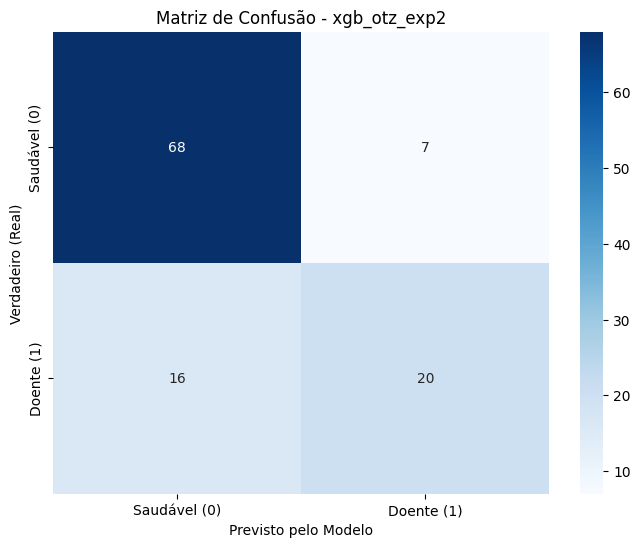

In [28]:
# Avaliar resultados e salvar
y_pred_otz_exp2 = experimento_2.best_model.predict(X_test_exp2)
y_prob_otz_exp2 = experimento_2.best_model.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_otz_exp2, y_prob_otz_exp2, 'xgb_otz_exp2')
save_results(y_pred_otz_exp2, y_prob_otz_exp2, 'xgb_otz_exp2', caminho)